In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from matplotlib.colors import Normalize
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")
if device == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using device: cuda
GPU: NVIDIA RTX A5500
Memory: 25.3 GB


## 1. Define Mess3 HMM

In [3]:
# Token-labeled transition matrices T^(x)_{i,j} = Pr(x, s_j | s_i)
# Rows = source state, Cols = destination state
T_A = np.array([
    [0.765,   0.00375, 0.00375],
    [0.0425,  0.0675,  0.00375],
    [0.0425,  0.00375, 0.0675 ]
])

T_B = np.array([
    [0.0675,  0.0425,  0.00375],
    [0.00375, 0.765,   0.00375],
    [0.00375, 0.0425,  0.0675 ]
])

T_C = np.array([
    [0.0675,  0.00375, 0.0425 ],
    [0.00375, 0.0675,  0.0425 ],
    [0.00375, 0.00375, 0.765  ]
])

T_matrices = [T_A, T_B, T_C]  # indexed by token: 0=A, 1=B, 2=C
TOKEN_NAMES = ['A', 'B', 'C']

# Full transition matrix T = sum_x T^(x)
T_full = T_A + T_B + T_C

# Verify rows sum to 1
print("Row sums of T_A:", T_A.sum(axis=1))
print("Row sums of T_B:", T_B.sum(axis=1))
print("Row sums of T_C:", T_C.sum(axis=1))
print("Row sums of T_full:", T_full.sum(axis=1))

# Stationary distribution (left eigenvector of T_full with eigenvalue 1)
eigenvalues, eigenvectors = np.linalg.eig(T_full.T)
idx = np.argmin(np.abs(eigenvalues - 1.0))
pi = np.real(eigenvectors[:, idx])
pi = pi / pi.sum()
print(f"\nStationary distribution π = {pi}")
print(f"(Should be uniform [1/3, 1/3, 1/3] by symmetry)")

Row sums of T_A: [0.7725  0.11375 0.11375]
Row sums of T_B: [0.11375 0.7725  0.11375]
Row sums of T_C: [0.11375 0.11375 0.7725 ]
Row sums of T_full: [1. 1. 1.]

Stationary distribution π = [0.33333333 0.33333333 0.33333333]
(Should be uniform [1/3, 1/3, 1/3] by symmetry)


## 2. Generate Mess3 Sequences with Ground-Truth States

In [4]:
def sample_mess3_sequence(length, rng=None):
    """Sample sequence from the Mess3 HMM.
    Returns:
        tokens: list of ints (0=A, 1=B, 2=C)
        hidden_states: list of ints (0, 1, 2)
    """
    if rng is None:
        rng = np.random.default_rng()
    
    # Start from stationary distribution
    state = rng.choice(3, p=pi)
    tokens = []
    hidden_states = []
    
    for _ in range(length):
        # For current state, compute emission+transition probabilities
        # P(token=x, next_state=j | current_state=state) = T_matrices[x][state, j]
        probs = np.array([T_matrices[x][state, :].sum() for x in range(3)])
        token = rng.choice(3, p=probs)
        
        # Transition to next state given token emitted
        trans_probs = T_matrices[token][state, :]
        trans_probs = trans_probs / trans_probs.sum()
        next_state = rng.choice(3, p=trans_probs)
        
        tokens.append(token)
        hidden_states.append(state)
        state = next_state
    
    return tokens, hidden_states


def compute_belief_states(tokens, initial_belief=None):
    """Compute the sequence of belief states given observed tokens.
    
    The belief state after seeing tokens x_0, ..., x_n is:
        η = (η_0 T^(x_0) T^(x_1) ... T^(x_n)) / normalization
    
    We return the belief state BEFORE seeing each token (i.e., the belief
    state that represents the posterior given all tokens seen so far).
    
    Returns:
        beliefs: np.array of shape (len(tokens)+1, 3)
            beliefs[0] = initial belief (before any tokens)
            beliefs[t] = belief after seeing tokens[0:t]
    """
    if initial_belief is None:
        initial_belief = pi.copy()
    
    beliefs = [initial_belief.copy()]
    eta = initial_belief.copy()
    
    for token in tokens:
        # Bayesian belief update: η' = η T^(x) / (η T^(x) 1)
        eta_new = eta @ T_matrices[token]
        norm = eta_new.sum()
        if norm > 0:
            eta_new = eta_new / norm
        eta = eta_new
        beliefs.append(eta.copy())
    
    return np.array(beliefs)


# Generate a long sequence to visualize the fractal
rng = np.random.default_rng(42)
long_tokens, long_hidden = sample_mess3_sequence(100000, rng=rng)
long_beliefs = compute_belief_states(long_tokens)

print(f"Generated {len(long_tokens)} tokens")
print(f"Token distribution: A={long_tokens.count(0)/len(long_tokens):.3f}, "
      f"B={long_tokens.count(1)/len(long_tokens):.3f}, "
      f"C={long_tokens.count(2)/len(long_tokens):.3f}")
print(f"Belief states shape: {long_beliefs.shape}")

Generated 100000 tokens
Token distribution: A=0.328, B=0.334, C=0.338
Belief states shape: (100001, 3)


## 3. Visualize Ground-Truth Belief State Geometry

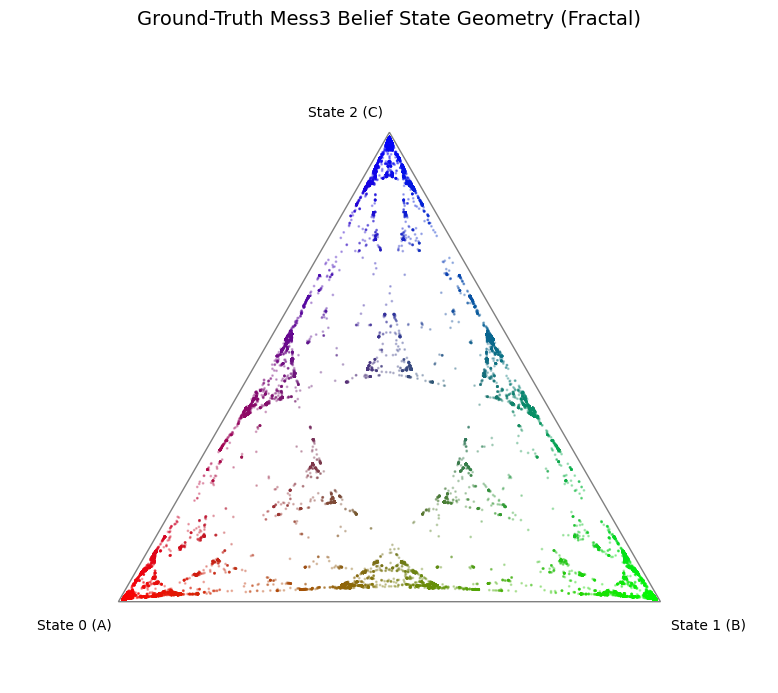

In [7]:
def beliefs_to_cartesian(beliefs):
    """Convert belief states (barycentric coords) to 2D Cartesian coords for plotting.
    Maps the 2-simplex to an equilateral triangle.
    """
    # Vertices of equilateral triangle
    v0 = np.array([0, 0])          # State 0 (A)
    v1 = np.array([1, 0])          # State 1 (B)  
    v2 = np.array([0.5, np.sqrt(3)/2])  # State 2 (C)
    
    x = beliefs[:, 0] * v0[0] + beliefs[:, 1] * v1[0] + beliefs[:, 2] * v2[0]
    y = beliefs[:, 0] * v0[1] + beliefs[:, 1] * v1[1] + beliefs[:, 2] * v2[1]
    return x, y


def beliefs_to_colors(beliefs):
    """Use belief distributions as RGB colors (following Shai et al.)."""
    colors = beliefs.copy()
    # Normalize for visibility
    colors = np.clip(colors, 0, 1)
    return colors


# Plot the ground truth fractal
fig, ax = plt.subplots(1, 1, figsize=(8, 7))

# Use beliefs after some burn-in (skip initial transient)
plot_beliefs = long_beliefs[100:]
x, y = beliefs_to_cartesian(plot_beliefs)
colors = beliefs_to_colors(plot_beliefs)

ax.scatter(x, y, c=colors, s=1, alpha=0.3, rasterized=True)

# Draw simplex boundary
triangle = plt.Polygon([[0,0],[1,0],[0.5,np.sqrt(3)/2]], fill=False, edgecolor='gray', linewidth=1)
ax.add_patch(triangle)

# Label vertices
ax.annotate('State 0 (A)', xy=(0, 0), xytext=(-0.15, -0.05), fontsize=10)
ax.annotate('State 1 (B)', xy=(1, 0), xytext=(1.02, -0.05), fontsize=10)
ax.annotate('State 2 (C)', xy=(0.5, np.sqrt(3)/2), xytext=(0.35, np.sqrt(3)/2+0.03), fontsize=10)

ax.set_xlim(-0.2, 1.2)
ax.set_ylim(-0.15, 1.05)
ax.set_aspect('equal')
ax.set_title('Ground-Truth Mess3 Belief State Geometry (Fractal)', fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.show()

## 4. Prepare Mess3 In-Context Sequences

In [8]:
# Load Llama 3.2-3B via TransformerLens
import transformer_lens as tl

MODEL_NAME = "meta-llama/Llama-3.2-3B"

print(f"Loading {MODEL_NAME}...")
model = tl.HookedTransformer.from_pretrained(
    MODEL_NAME,
    device=device,
    torch_dtype=torch.float16,
)
model.eval()
print(f"Model loaded. {model.cfg.n_layers} layers, d_model={model.cfg.d_model}")
print(f"Context window: {model.cfg.n_ctx}")

2026-02-19 23:30:25.031164: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Loading meta-llama/Llama-3.2-3B...


`torch_dtype` is deprecated! Use `dtype` instead!
Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00,  2.83it/s]


Loaded pretrained model meta-llama/Llama-3.2-3B into HookedTransformer
Model loaded. 28 layers, d_model=3072
Context window: 2048


In [9]:
# Determine single-token IDs for A, B, C
tokenizer = model.tokenizer

# Check tokenization of our token choices
for char in ['A', 'B', 'C', ' A', ' B', ' C']:
    ids = tokenizer.encode(char, add_special_tokens=False)
    print(f"'{char}' -> token IDs: {ids} -> decoded: {[tokenizer.decode([i]) for i in ids]}")

# Use format: "A, B, C, A, A, B, ..." (comma-separated)
test_str = "A, B, C, A, A, B, C"
test_ids = tokenizer.encode(test_str, add_special_tokens=False)
print(f"\nTest string: '{test_str}'")
print(f"Token IDs: {test_ids}")
print(f"Decoded tokens: {[tokenizer.decode([i]) for i in test_ids]}")

'A' -> token IDs: [32] -> decoded: ['A']
'B' -> token IDs: [33] -> decoded: ['B']
'C' -> token IDs: [34] -> decoded: ['C']
' A' -> token IDs: [362] -> decoded: [' A']
' B' -> token IDs: [426] -> decoded: [' B']
' C' -> token IDs: [356] -> decoded: [' C']

Test string: 'A, B, C, A, A, B, C'
Token IDs: [32, 11, 426, 11, 356, 11, 362, 11, 362, 11, 426, 11, 356]
Decoded tokens: ['A', ',', ' B', ',', ' C', ',', ' A', ',', ' A', ',', ' B', ',', ' C']


In [10]:
def mess3_tokens_to_prompt(tokens, separator=', '):
    """Convert Mess3 token indices to a text prompt."""
    return separator.join([TOKEN_NAMES[t] for t in tokens])


def find_letter_token_positions(input_ids, tokenizer):
    """Find which positions in the tokenized input correspond to A, B, or C tokens.
    
    Returns:
        positions: list of (position_index, mess3_token_index) pairs
    """
    positions = []
    # Get the token IDs for A, B, C (with and without leading space)
    letter_ids = {}
    for i, char in enumerate(TOKEN_NAMES):
        for variant in [char, f' {char}']:
            ids = tokenizer.encode(variant, add_special_tokens=False)
            if len(ids) == 1:
                letter_ids[ids[0]] = i
    
    for pos, tid in enumerate(input_ids):
        if tid in letter_ids:
            positions.append((pos, letter_ids[tid]))
    
    return positions, letter_ids


# Test the mapping
test_tokens = [0, 1, 2, 0, 0, 1]  # A, B, C, A, A, B
test_prompt = mess3_tokens_to_prompt(test_tokens)
test_input_ids = tokenizer.encode(test_prompt, add_special_tokens=False)
positions, letter_ids = find_letter_token_positions(test_input_ids, tokenizer)

print(f"Prompt: '{test_prompt}'")
print(f"Input IDs: {test_input_ids}")
print(f"Letter token mapping: {letter_ids}")
print(f"Letter positions: {positions}")
print(f"Number of Mess3 tokens: {len(test_tokens)}, detected: {len(positions)}")

Prompt: 'A, B, C, A, A, B'
Input IDs: [32, 11, 426, 11, 356, 11, 362, 11, 362, 11, 426]
Letter token mapping: {32: 0, 362: 0, 33: 1, 426: 1, 34: 2, 356: 2}
Letter positions: [(0, 0), (2, 1), (4, 2), (6, 0), (8, 0), (10, 1)]
Number of Mess3 tokens: 6, detected: 6


## 5. Extract Residual Stream

In [11]:
# Configuration

# Number of independent sequences to process
N_SEQUENCES = 20

# Length of each Mess3 sequence (in Mess3 tokens, not model tokens)
# This should be long enough for the simplex to potentially emerge
SEQ_LENGTH = 500

# Layers to analyze
# Llama 3.2 3B has 28 layers; look at a subset
LAYERS_TO_ANALYZE = list(range(0, model.cfg.n_layers, 4)) + [model.cfg.n_layers - 1]
LAYERS_TO_ANALYZE = sorted(set(LAYERS_TO_ANALYZE))
print(f"Will analyze layers: {LAYERS_TO_ANALYZE}")
print(f"Generating {N_SEQUENCES} sequences of length {SEQ_LENGTH}")

Will analyze layers: [0, 4, 8, 12, 16, 20, 24, 27]
Generating 20 sequences of length 500


In [12]:
# Generate sequences and collect activations

all_activations = {layer: [] for layer in LAYERS_TO_ANALYZE}  # layer -> list of (N_tokens, d_model)
all_beliefs = []     # list of (N_tokens, 3) arrays
all_positions = []   # list tracking the Mess3-token index within each sequence

rng = np.random.default_rng(123)

for seq_idx in tqdm(range(N_SEQUENCES), desc="Processing sequences"):
    # Generate Mess3 sequence
    tokens, hidden = sample_mess3_sequence(SEQ_LENGTH, rng=rng)
    
    # Compute ground-truth belief states
    # beliefs[t] = belief after seeing tokens[0:t]
    beliefs = compute_belief_states(tokens)
    # beliefs has shape (SEQ_LENGTH+1, 3)
    # beliefs[0] = prior (stationary), beliefs[1] = after 1st token, etc.
    
    # Convert to prompt
    prompt = mess3_tokens_to_prompt(tokens)
    
    # Tokenize
    input_ids = tokenizer.encode(prompt, add_special_tokens=True, return_tensors='pt')
    
    # Check if it fits in context window
    if input_ids.shape[1] > model.cfg.n_ctx:
        # Truncate the Mess3 sequence to fit
        # Binary search for the right length
        lo, hi = 10, SEQ_LENGTH
        while lo < hi:
            mid = (lo + hi + 1) // 2
            test_prompt = mess3_tokens_to_prompt(tokens[:mid])
            test_ids = tokenizer.encode(test_prompt, add_special_tokens=True)
            if len(test_ids) <= model.cfg.n_ctx:
                lo = mid
            else:
                hi = mid - 1
        tokens = tokens[:lo]
        beliefs = compute_belief_states(tokens)
        prompt = mess3_tokens_to_prompt(tokens)
        input_ids = tokenizer.encode(prompt, add_special_tokens=True, return_tensors='pt')
    
    input_ids_list = input_ids[0].tolist()
    
    # Find positions of A/B/C tokens
    positions, _ = find_letter_token_positions(input_ids_list, tokenizer)
    
    if len(positions) != len(tokens):
        print(f"Warning seq {seq_idx}: expected {len(tokens)} letter positions, got {len(positions)}")
        # Use the minimum
        n_use = min(len(positions), len(tokens))
        positions = positions[:n_use]
    
    # Run model and cache activations
    with torch.no_grad():
        _, cache = model.run_with_cache(
            input_ids.to(device),
            names_filter=[f"blocks.{l}.hook_resid_post" for l in LAYERS_TO_ANALYZE]
        )
    
    # Extract activations at letter positions
    for layer in LAYERS_TO_ANALYZE:
        hook_name = f"blocks.{layer}.hook_resid_post"
        layer_acts = cache[hook_name][0]  # (seq_len, d_model)
        
        # Get activations at letter positions
        pos_indices = [p[0] for p in positions]
        letter_acts = layer_acts[pos_indices].cpu().float().numpy()  # (n_letters, d_model)
        all_activations[layer].append(letter_acts)
    
    # Store belief states (beliefs[1:] corresponds to belief AFTER each token)
    n_use = len(positions)
    all_beliefs.append(beliefs[1:n_use+1])  # belief after seeing each token
    
    # Store sequence position indices
    all_positions.append(np.arange(n_use))
    
    # Free cache memory
    del cache
    torch.cuda.empty_cache()

# Concatenate across sequences
for layer in LAYERS_TO_ANALYZE:
    all_activations[layer] = np.concatenate(all_activations[layer], axis=0)
all_beliefs_flat = np.concatenate(all_beliefs, axis=0)
all_positions_flat = np.concatenate(all_positions, axis=0)

print(f"\nTotal datapoints: {len(all_beliefs_flat)}")
print(f"Activations shape per layer: {all_activations[LAYERS_TO_ANALYZE[0]].shape}")
print(f"Beliefs shape: {all_beliefs_flat.shape}")
print(f"Position range: {all_positions_flat.min()} to {all_positions_flat.max()}")

Processing sequences: 100%|██████████| 20/20 [00:04<00:00,  4.10it/s]



Total datapoints: 10000
Activations shape per layer: (10000, 3072)
Beliefs shape: (10000, 3)
Position range: 0 to 499


## 6. Find Belief Simplex in Residual Stream

In [13]:
# Fit linear regression for each layer (on ALL context positions)

regression_results = {}

for layer in LAYERS_TO_ANALYZE:
    acts = all_activations[layer]
    beliefs = all_beliefs_flat
    
    # Train/test split for cross-validation
    X_train, X_test, y_train, y_test = train_test_split(
        acts, beliefs, test_size=0.2, random_state=42
    )
    
    reg = LinearRegression()
    reg.fit(X_train, y_train)
    
    # Evaluate
    y_pred_train = reg.predict(X_train)
    y_pred_test = reg.predict(X_test)
    
    mse_train = mean_squared_error(y_train, y_pred_train)
    mse_test = mean_squared_error(y_test, y_pred_test)
    
    # Project all activations
    projected = reg.predict(acts)
    
    regression_results[layer] = {
        'model': reg,
        'mse_train': mse_train,
        'mse_test': mse_test,
        'projected': projected,
    }
    
    print(f"Layer {layer:2d}: MSE train={mse_train:.6f}, MSE test={mse_test:.6f}")

Layer  0: MSE train=0.003133, MSE test=0.003302
Layer  4: MSE train=0.000123, MSE test=0.000356
Layer  8: MSE train=0.000188, MSE test=0.000749
Layer 12: MSE train=0.000462, MSE test=0.001628
Layer 16: MSE train=0.000476, MSE test=0.001769
Layer 20: MSE train=0.000533, MSE test=0.001862
Layer 24: MSE train=0.000528, MSE test=0.002107
Layer 27: MSE train=0.000590, MSE test=0.001842


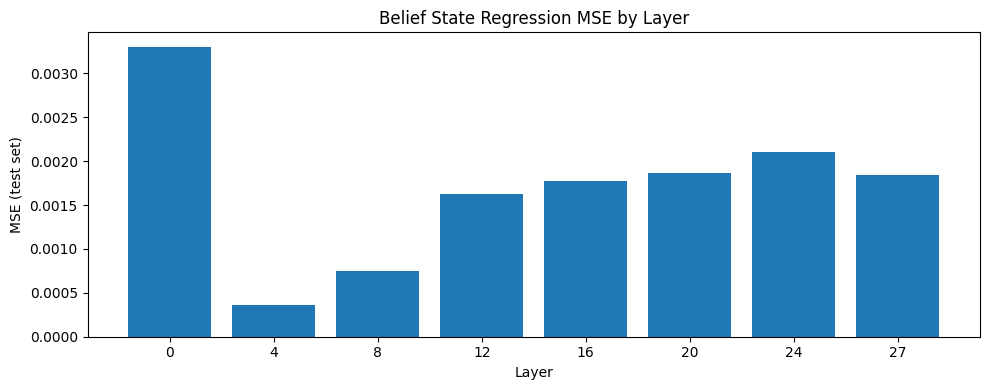

In [25]:
# Plot MSE across layers

fig, ax = plt.subplots(1, 1, figsize=(10, 4))

layers = sorted(regression_results.keys())
mse_train = [regression_results[l]['mse_test'] for l in layers]

ax.bar(range(len(layers)), mse_train, tick_label=[str(l) for l in layers])
ax.set_xlabel('Layer')
ax.set_ylabel('MSE (test set)')
ax.set_title('Belief State Regression MSE by Layer')
plt.tight_layout()
plt.savefig('mse.pdf')
plt.show()

## 7. Visualize Projected Belief States by Layer

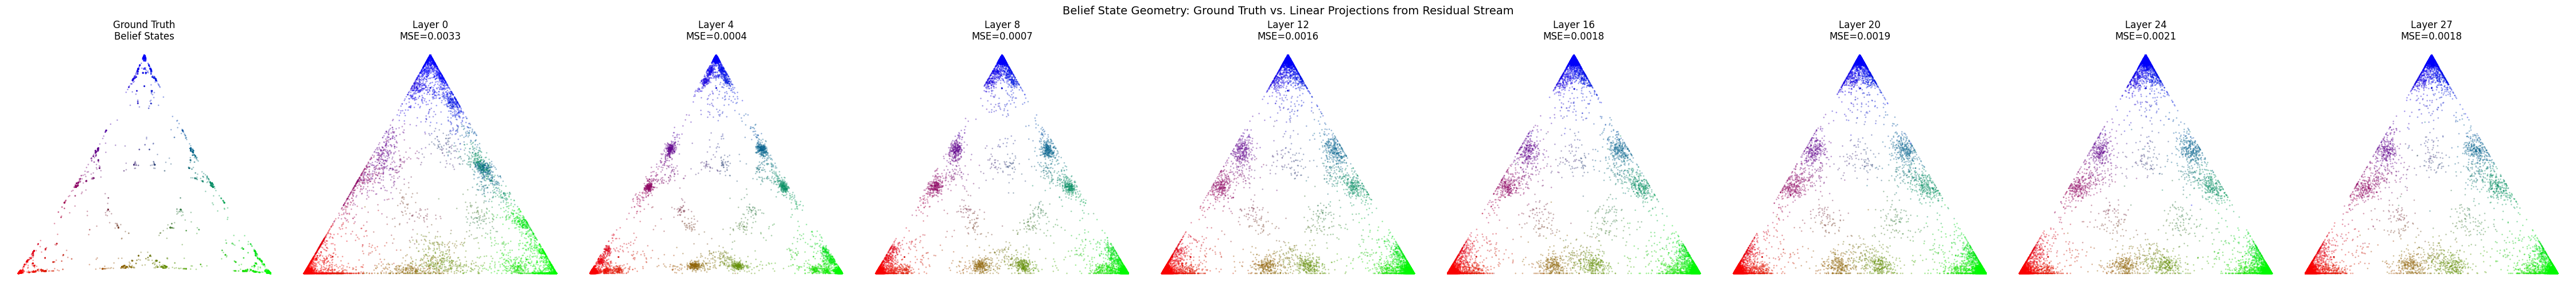

In [23]:
# Simplex visualizations for select layers

# Determine which layers to plot
show_layers = LAYERS_TO_ANALYZE
show_layers = sorted(set(show_layers))

n_show = len(show_layers) + 1  # +1 for ground truth
fig, axes = plt.subplots(1, n_show, figsize=(5*n_show, 5))

# Ground truth
ax = axes[0]
gt_x, gt_y = beliefs_to_cartesian(all_beliefs_flat)
gt_colors = beliefs_to_colors(all_beliefs_flat)
ax.scatter(gt_x, gt_y, c=gt_colors, s=1, alpha=0.3, rasterized=True)
ax.set_title('Ground Truth\nBelief States', fontsize=12)
ax.set_aspect('equal')
ax.axis('off')

# Per-layer projections
for idx, layer in enumerate(show_layers):
    ax = axes[idx + 1]
    projected = regression_results[layer]['projected']
    
    # Clip to valid probability simplex
    proj_clipped = np.clip(projected, 0, 1)
    row_sums = proj_clipped.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    proj_clipped = proj_clipped / row_sums
    
    px, py = beliefs_to_cartesian(proj_clipped)
    p_colors = beliefs_to_colors(all_beliefs_flat)  # color by ground truth
    
    ax.scatter(px, py, c=p_colors, s=1, alpha=0.3, rasterized=True)
    mse = regression_results[layer]['mse_test']
    ax.set_title(f'Layer {layer}\nMSE={mse:.4f}', fontsize=12)
    ax.set_aspect('equal')
    ax.axis('off')

fig.suptitle('Belief State Geometry: Ground Truth vs. Linear Projections from Residual Stream', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('mess3.pdf')
plt.show()